# Open in Colab
<a target="_blank" href="https://colab.research.google.com/github/Nicolepcx/ai-agents-the-definitive-guide/blob/main/CH11/ch11_agent_cost_estimator_based_on_topology.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [ ]:
!pip install genai-prices

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 1.9 MB/s eta 0:00:00


In [ ]:
# =====================================================================
# API cost estimator for agent architectures
# Architecture behavior × deployment profile × realistic cost knobs:
#   - calls_per_request with low/high bands (dominant source of variance)
#   - cache_hit_rate per step (prefix caching discount on input tokens)
# Swap DEPLOYMENT_PROFILES entries to compare the "same architecture,
# different model mix" trade-off without touching the architecture.
# =====================================================================

from __future__ import annotations

from dataclasses import dataclass
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from genai_prices import calc_price


# ---------------------------------------------------------------------
# Architecture definitions — behavior, not model IDs.
# Optional fields:
#   calls_per_request_low / calls_per_request_high  — realistic band
#   cache_hit_rate                                  — fraction of input
#                                                     served from cache
# ---------------------------------------------------------------------
ARCHITECTURES = {
    "Single-shot": [
        # One call, nothing to cache against.
        {"step": "answer", "role": "reasoning_medium",
         "calls_per_request": 1.0,
         "input_tokens": 3500, "output_tokens": 700,
         "cache_hit_rate": 0.0},
    ],
    "ReAct": [
        # First call establishes the prefix — no cache yet.
        {"step": "planner", "role": "reasoning_medium",
         "calls_per_request": 1.0,
         "input_tokens": 2500, "output_tokens": 300,
         "cache_hit_rate": 0.0},
        # Tool loop is the dominant cost knob. Real traces span 1-8+ steps;
        # the system prompt + tool descriptions cache well across iterations.
        {"step": "tool_reasoning_loop", "role": "reasoning_medium",
         "calls_per_request": 3.0,
         "calls_per_request_low": 1.0, "calls_per_request_high": 8.0,
         "input_tokens": 2200, "output_tokens": 250,
         "cache_hit_rate": 0.60},
        {"step": "final_answer", "role": "reasoning_medium",
         "calls_per_request": 1.0,
         "input_tokens": 3000, "output_tokens": 700,
         "cache_hit_rate": 0.40},
    ],
    "Supervisor multi-agent": [
        {"step": "router", "role": "routing_light",
         "calls_per_request": 1.0,
         "input_tokens": 1500, "output_tokens": 120,
         "cache_hit_rate": 0.0},
        {"step": "retrieval_agent", "role": "reasoning_medium",
         "calls_per_request": 1.0,
         "input_tokens": 2200, "output_tokens": 250,
         "cache_hit_rate": 0.30},
        # Specialist fires conditionally. Heavy model, sensitive to the band.
        {"step": "specialist_reasoner", "role": "reasoning_heavy",
         "calls_per_request": 0.6,
         "calls_per_request_low": 0.3, "calls_per_request_high": 0.9,
         "input_tokens": 5000, "output_tokens": 900,
         "cache_hit_rate": 0.35},
        {"step": "critic", "role": "reasoning_medium",
         "calls_per_request": 0.5,
         "calls_per_request_low": 0.0, "calls_per_request_high": 1.0,
         "input_tokens": 2500, "output_tokens": 250,
         "cache_hit_rate": 0.30},
        {"step": "synthesizer", "role": "reasoning_medium",
         "calls_per_request": 1.0,
         "input_tokens": 3500, "output_tokens": 700,
         "cache_hit_rate": 0.20},
    ],
}


# ---------------------------------------------------------------------
# Deployment profiles — role → (provider, model). Swap to compare.
# ---------------------------------------------------------------------
DEPLOYMENT_PROFILES = {
    "openai_default": {
        "routing_light":    {"provider": "openai", "model": "gpt-5-nano"},
        "reasoning_medium": {"provider": "openai", "model": "gpt-5-mini"},
        "reasoning_heavy":  {"provider": "openai", "model": "gpt-5"},
    },
    "openai_cost_optimized": {
        # Downgrade the heavy role — see whether the specialist_reasoner
        # step still carries its weight at mini pricing.
        "routing_light":    {"provider": "openai", "model": "gpt-5-nano"},
        "reasoning_medium": {"provider": "openai", "model": "gpt-5-mini"},
        "reasoning_heavy":  {"provider": "openai", "model": "gpt-5-mini"},
    },
}


# ---------------------------------------------------------------------
# Minimal usage object expected by genai_prices
# ---------------------------------------------------------------------
@dataclass
class PricingUsage:
    input_tokens: int = 0
    output_tokens: int = 0

    cached_input_tokens: int = 0
    cache_creation_input_tokens: int = 0
    cache_read_input_tokens: int = 0

    input_audio_tokens: int = 0
    output_audio_tokens: int = 0

    reasoning_tokens: int = 0

    def __getattr__(self, name: str) -> Any:
        return 0


# ---------------------------------------------------------------------
# Step result
# ---------------------------------------------------------------------
@dataclass(frozen=True)
class StepResult:
    deployment: str
    architecture: str
    step: str
    role: str
    provider: str
    model: str
    calls_point: float
    calls_low: float
    calls_high: float
    input_tokens_per_call: int
    fresh_input_per_call: int
    cached_input_per_call: int
    output_tokens_per_call: int
    cache_hit_rate: float
    cost_per_call: float
    expected_input_tokens: float
    expected_output_tokens: float
    expected_total_tokens: float
    expected_cost_low: float
    expected_cost_point: float
    expected_cost_high: float


# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------
def extract_price(result: Any) -> float:
    for attr in ("total_price", "price", "total_cost", "cost", "amount", "usd"):
        if hasattr(result, attr):
            value = getattr(result, attr)
            if value is not None:
                return float(value)
    if hasattr(result, "__dict__"):
        for value in result.__dict__.values():
            try:
                return float(value)
            except Exception:
                continue
    raise TypeError(f"Could not extract price from result object: {result!r}")


def calc_full_call_price(
    fresh_input_tokens: int,
    cached_input_tokens: int,
    output_tokens: int,
    model: str,
    provider: str,
) -> float:
    """Price one call. fresh + cached input are billed at different rates
    by the provider; genai_prices honors the split via cached_input_tokens."""
    usage = PricingUsage(
        input_tokens=int(fresh_input_tokens),
        cached_input_tokens=int(cached_input_tokens),
        output_tokens=int(output_tokens),
    )
    result = calc_price(usage=usage, model_ref=model, provider_id=provider)
    return extract_price(result)


def resolve_step(step: dict, deployment_profile: dict) -> dict:
    role = step["role"]
    mapping = deployment_profile[role]
    return {**step, "provider": mapping["provider"], "model": mapping["model"]}


def estimate_architecture_costs(
    architectures: dict,
    deployment_profiles: dict,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Estimate across ALL deployment profiles. Returns (steps_df, arch_df)
    where arch_df has one row per (deployment, architecture)."""
    rows: list[dict] = []

    for deployment_name, deployment in deployment_profiles.items():
        for architecture_name, steps in architectures.items():
            for step in steps:
                resolved = resolve_step(step, deployment)

                calls_point = float(resolved["calls_per_request"])
                calls_low = float(resolved.get("calls_per_request_low", calls_point))
                calls_high = float(resolved.get("calls_per_request_high", calls_point))
                input_tokens = int(resolved["input_tokens"])
                output_tokens = int(resolved["output_tokens"])
                cache_hit_rate = float(resolved.get("cache_hit_rate", 0.0))

                cached_input = int(round(input_tokens * cache_hit_rate))
                fresh_input = input_tokens - cached_input

                cost_per_call = calc_full_call_price(
                    fresh_input_tokens=fresh_input,
                    cached_input_tokens=cached_input,
                    output_tokens=output_tokens,
                    model=resolved["model"],
                    provider=resolved["provider"],
                )

                rows.append(StepResult(
                    deployment=deployment_name,
                    architecture=architecture_name,
                    step=resolved["step"],
                    role=resolved["role"],
                    provider=resolved["provider"],
                    model=resolved["model"],
                    calls_point=calls_point,
                    calls_low=calls_low,
                    calls_high=calls_high,
                    input_tokens_per_call=input_tokens,
                    fresh_input_per_call=fresh_input,
                    cached_input_per_call=cached_input,
                    output_tokens_per_call=output_tokens,
                    cache_hit_rate=cache_hit_rate,
                    cost_per_call=cost_per_call,
                    expected_input_tokens=calls_point * input_tokens,
                    expected_output_tokens=calls_point * output_tokens,
                    expected_total_tokens=calls_point * (input_tokens + output_tokens),
                    expected_cost_low=calls_low * cost_per_call,
                    expected_cost_point=calls_point * cost_per_call,
                    expected_cost_high=calls_high * cost_per_call,
                ).__dict__)

    steps_df = pd.DataFrame(rows)

    arch_df = (
        steps_df.groupby(["deployment", "architecture"], as_index=False)
        .agg(
            total_input_tokens=("expected_input_tokens", "sum"),
            total_output_tokens=("expected_output_tokens", "sum"),
            total_tokens=("expected_total_tokens", "sum"),
            total_cost_low=("expected_cost_low", "sum"),
            total_cost_point=("expected_cost_point", "sum"),
            total_cost_high=("expected_cost_high", "sum"),
        )
    )

    # Multipliers relative to Single-shot WITHIN each deployment.
    for dep in arch_df["deployment"].unique():
        mask = arch_df["deployment"] == dep
        single = arch_df[mask & (arch_df["architecture"] == "Single-shot")]
        if single.empty:
            continue
        baseline_tokens = single["total_tokens"].iloc[0]
        baseline_cost = single["total_cost_point"].iloc[0]
        arch_df.loc[mask, "token_multiplier"] = arch_df.loc[mask, "total_tokens"] / baseline_tokens
        arch_df.loc[mask, "cost_multiplier"] = arch_df.loc[mask, "total_cost_point"] / baseline_cost

    arch_df = arch_df.sort_values(["deployment", "token_multiplier"]).reset_index(drop=True)
    return steps_df, arch_df


# ---------------------------------------------------------------------
# Run the estimator across all deployments
# ---------------------------------------------------------------------
steps_df, arch_df = estimate_architecture_costs(
    architectures=ARCHITECTURES,
    deployment_profiles=DEPLOYMENT_PROFILES,
)

print("Architecture-level summary (per deployment):")
print()
print(arch_df.to_string(index=False))
print()

# Quick cross-deployment delta — the whole reason the profile abstraction exists.
pivot = arch_df.pivot(index="architecture", columns="deployment",
                       values="total_cost_point").round(4)
pivot["delta_pct"] = ((pivot["openai_default"] - pivot["openai_cost_optimized"])
                      / pivot["openai_default"] * 100).round(1)
print("Cost per request by deployment (USD):")
print(pivot.to_string())


Architecture-level summary (per deployment):

           deployment           architecture  total_input_tokens  total_output_tokens  total_tokens  total_cost_low  total_cost_point  total_cost_high  token_multiplier  cost_multiplier
openai_cost_optimized            Single-shot              3500.0                700.0        4200.0        0.002275          0.002275         0.002275          1.000000         1.000000
openai_cost_optimized Supervisor multi-agent             11450.0               1735.0       13185.0        0.003892          0.005144         0.006397          3.139286         2.261209
openai_cost_optimized                  ReAct             12100.0               1750.0       13850.0        0.003795          0.005235         0.008835          3.297619         2.301099
       openai_default            Single-shot              3500.0                700.0        4200.0        0.002275          0.002275         0.002275          1.000000         1.000000
       openai_default Su

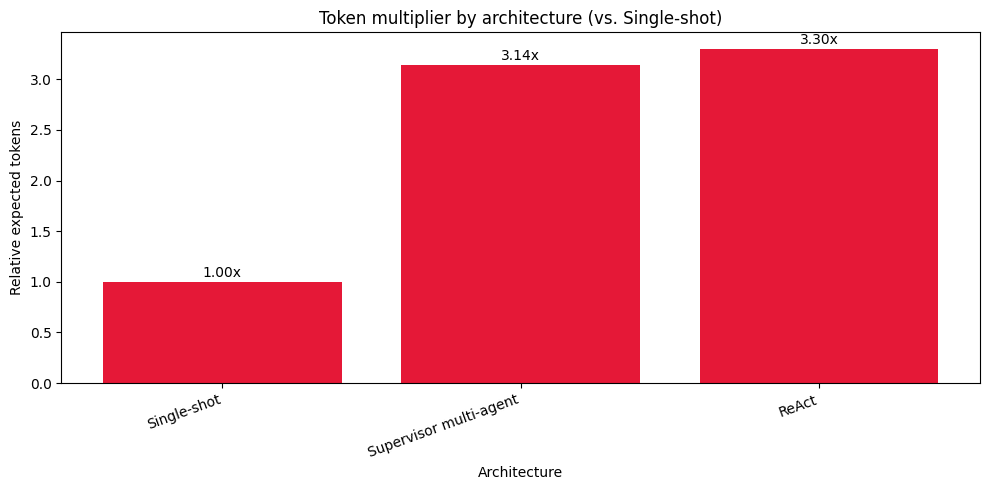

In [ ]:
# ---------------------------------------------------------------------
# Plot 1: Token multiplier by architecture (deployment-independent —
# tokens are a property of the topology, not the model mix).
# ---------------------------------------------------------------------
arch_tokens = (arch_df.drop_duplicates("architecture")
               .set_index("architecture")
               .sort_values("token_multiplier"))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(arch_tokens.index, arch_tokens["token_multiplier"], color="#E51837")
ax.set_title("Token multiplier by architecture (vs. Single-shot)")
ax.set_ylabel("Relative expected tokens")
ax.set_xlabel("Architecture")
for i, v in enumerate(arch_tokens["token_multiplier"]):
    ax.text(i, v + 0.05, f"{v:.2f}x", ha="center")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


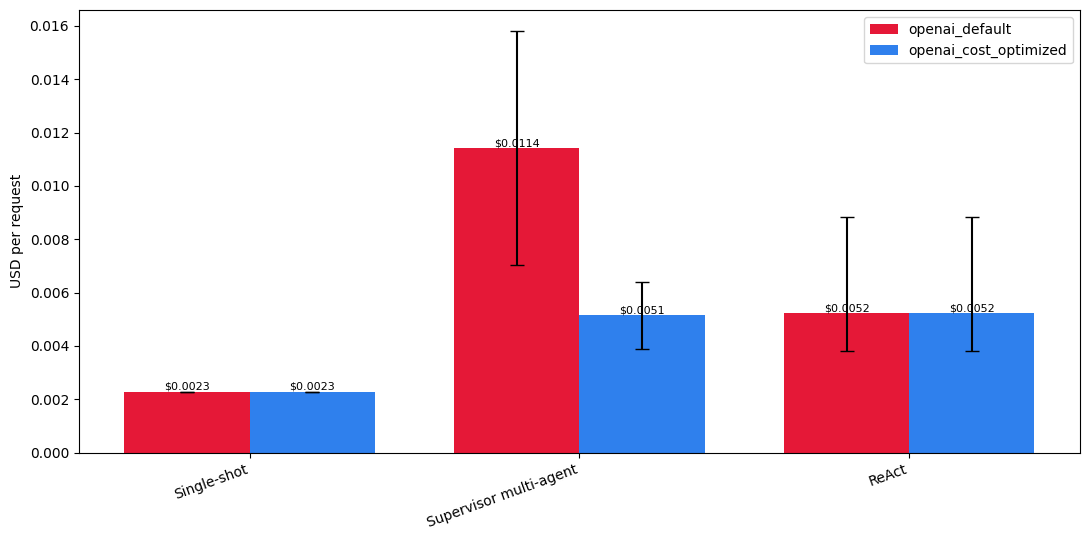

In [ ]:
# ---------------------------------------------------------------------
# Plot 2: Cost per request — grouped by deployment, error bars show the
# low/high band from calls_per_request uncertainty. The "same topology,
# different deployment" comparison is the whole reason we split behavior
# from deployment.
# ---------------------------------------------------------------------
architectures = list(arch_df["architecture"].drop_duplicates())
deployments = list(DEPLOYMENT_PROFILES.keys())
x = np.arange(len(architectures))
width = 0.38
colors = {"openai_default": "#E51837", "openai_cost_optimized": "#2F80ED"}

fig, ax = plt.subplots(figsize=(11, 5.5))
for i, dep in enumerate(deployments):
    sub = (arch_df[arch_df["deployment"] == dep]
           .set_index("architecture").reindex(architectures))
    point = sub["total_cost_point"].values
    err_low = point - sub["total_cost_low"].values
    err_high = sub["total_cost_high"].values - point
    bars = ax.bar(x + (i - 0.5) * width, point, width,
                  yerr=[err_low, err_high], capsize=5,
                  label=dep, color=colors.get(dep, "#888"))
    for xi, p in zip(x + (i - 0.5) * width, point):
        ax.text(xi, p, f"${p:.4f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(architectures, rotation=20, ha="right")
#ax.set_title("Estimated API cost per request\n"
#             "(error bars = low/high band on calls_per_request)")
ax.set_ylabel("USD per request")
ax.legend()
plt.tight_layout()
plt.show()


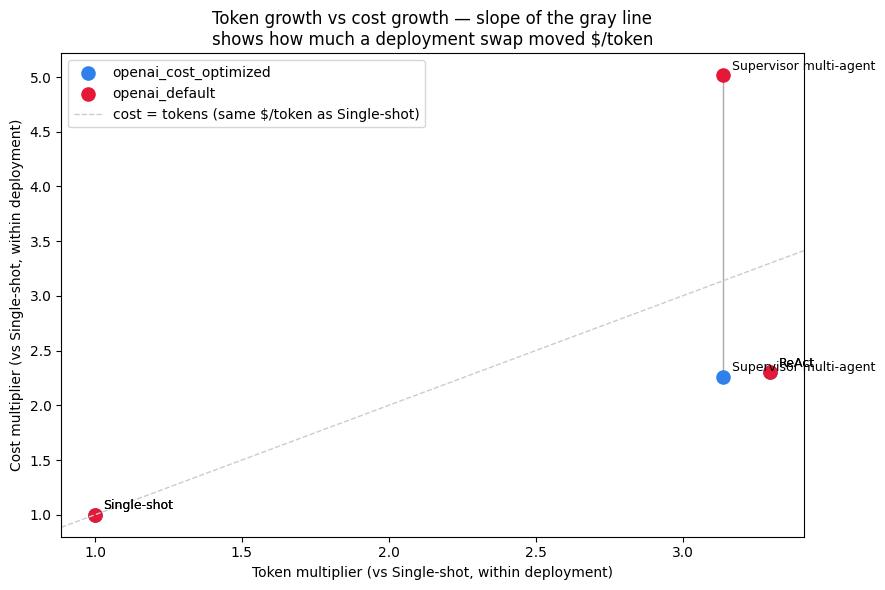

In [ ]:
# ---------------------------------------------------------------------
# Plot 3: Token growth vs cost growth, colored by deployment. Each
# architecture shows up twice — once per deployment. A line connects the
# two deployment points per architecture: the slope tells you how much
# moving the heavy role from gpt-5.4 → gpt-5.4-mini actually bought you.
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 6))

for arch in arch_df["architecture"].unique():
    sub = arch_df[arch_df["architecture"] == arch]
    xs = sub["token_multiplier"].values
    ys = sub["cost_multiplier"].values
    ax.plot(xs, ys, color="#aaa", linewidth=1, zorder=1)

for dep in arch_df["deployment"].unique():
    sub = arch_df[arch_df["deployment"] == dep]
    ax.scatter(sub["token_multiplier"], sub["cost_multiplier"],
               color=colors.get(dep, "#888"), s=90, label=dep, zorder=2)
    for _, row in sub.iterrows():
        ax.annotate(row["architecture"],
                    (row["token_multiplier"], row["cost_multiplier"]),
                    xytext=(6, 4), textcoords="offset points", fontsize=9)

ax.axline((1, 1), slope=1, color="#ccc", linestyle="--", linewidth=1,
          label="cost = tokens (same $/token as Single-shot)")
ax.set_xlabel("Token multiplier (vs Single-shot, within deployment)")
ax.set_ylabel("Cost multiplier (vs Single-shot, within deployment)")
ax.set_title("Token growth vs cost growth — slope of the gray line\n"
             "shows how much a deployment swap moved $/token")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()
